<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Statistical-Data-Analysis-2/blob/master/LAB_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SAD 2, Lab 11: Gibbs Sampling**

In many statistical models, especially Bayesian ones, we want to sample from a **joint distribution**  

$$
p(x_1, \dots, x_d),
$$  

but this distribution is often complicated and only known up to a constant. Direct sampling is usually impossible. The good news? It’s often **much easier to sample from the conditional distributions** of each variable given the others:  

$$
p(x_i \mid x_{-i}) \quad \text{for } i = 1, \dots, d.
$$  

The **Gibbs sampler** updates one variable at a time. For each variable:

1. Fix all the other variables at their current values.
2. Sample the variable from its conditional distribution.
3. Move to the next variable.

Repeating this process over and over creates a **Markov chain** whose stationary distribution is exactly the joint distribution we care about. Think of Gibbs as a special case of Metropolis-Hastings where every proposal is automatically accepted.

## Gibbs Sampling Step-by-Step

Start with an initial state:  

$$
\mathbf{x}^{(0)} = (x_1^{(0)}, \dots, x_d^{(0)}).
$$  

One iteration of Gibbs sampling looks like this:

$$
\begin{aligned}
x_1^{(t)} &\sim p(x_1 \mid x_2^{(t-1)}, \dots, x_d^{(t-1)}) \\
x_2^{(t)} &\sim p(x_2 \mid x_1^{(t)}, x_3^{(t-1)}, \dots, x_d^{(t-1)}) \\
&\vdots \\
x_d^{(t)} &\sim p(x_d \mid x_1^{(t)}, \dots, x_{d-1}^{(t)})
\end{aligned}
$$  

- Repeat for many iterations.  
- Discard the first few samples as **burn-in**.  
- The remaining samples are approximately from $p(x_1, \dots, x_d)$.

## Example: Diseases, Symptoms and Immune Responses

We consider the following situation:

- A person $i$ can be **sick** ($D_i = 1$) or **not sick** ($D_i = 0$).  
- If a person is sick, the immune response triggers ($IR_i = 1$) with probability $\alpha_1$; if the person is not sick, the immune response can still trigger with a small probability $\alpha_0$.

A person can show **three levels of symptoms** $S_i$:  

- $0$ - mild  
- $1$ - medium  
- $2$ - severe  

The probabilities of observing each symptom level depend on the combination of disease state $D_i$ and immune response $IR_i$. We encode these probabilities in a vector  

$$
\boldsymbol{\beta}_{d,ir} = (\beta_{d,ir,0}, \beta_{d,ir,1}, \beta_{d,ir,2}),
\quad d \in \{0,1\}, \, ir \in \{0,1\}
$$

where  

$$
\beta_{d,ir,j} = P(S_i = j \mid D_i = d, IR_i = ir), \quad j \in \{0,1,2\}.
$$




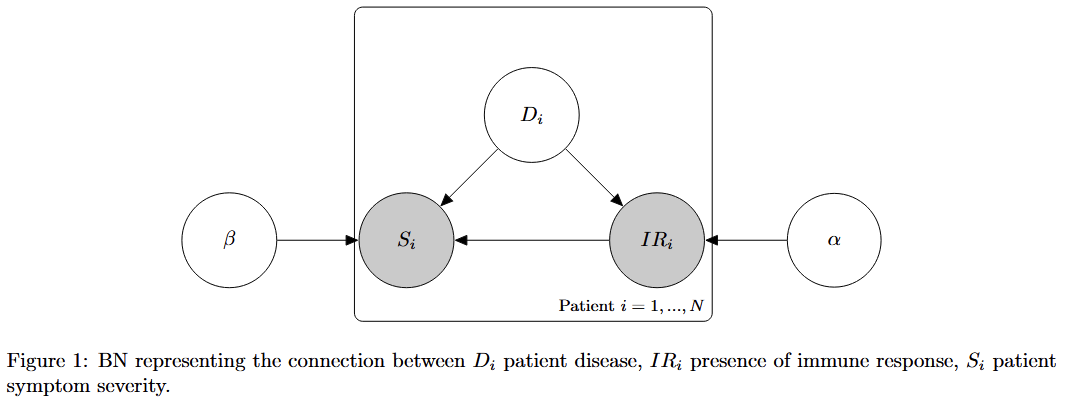

# Gibbs Sampling

Assume we observe $N$ individuals, and for each individual $i$ we can measure their **symptoms** $S_i$ and the **immune response** $IR_i$.  
We do **not** know their true disease state $D_i$, nor the underlying probabilities in the model, $\boldsymbol{\alpha} = (\alpha_0, \alpha_1)$ and $\boldsymbol{\beta} = \{\boldsymbol{\beta}_{d,ir}\}_{d \in \{0,1\}, ir \in \{0,1\}}$.  
We may have prior knowledge about their likely behavior (e.g., $\alpha_0$ should be small). These assumptions are used as **priors** on $D_i$, $\boldsymbol{\alpha}$, and $\boldsymbol{\beta}$.

To estimate the **posterior distributions** $P(D_i \mid S_i, IR_i)$, $P(\boldsymbol{\alpha} \mid \mathbf{S}, \mathbf{IR})$, and $P(\boldsymbol{\beta} \mid \mathbf{S}, \mathbf{IR})$, we use **Gibbs sampling**:

1. **Initialization:** Start with initial values
$$
D_i^{(1)}, \quad \boldsymbol{\alpha}^{(1)}, \quad \boldsymbol{\beta}^{(1)} \quad \text{for all } i=1,\dots,N,
$$
e.g., sampled from the priors.

2. **Iteration:** For $t = 2, \dots, T$:

   1. Sample the disease states from the conditional posterior:
   $$
   D_i^{(t)} \sim P(D_i \mid S_i, IR_i, \boldsymbol{\alpha}^{(t-1)}, \boldsymbol{\beta}^{(t-1)}), \quad i=1,\dots,N.
   $$
   2. Sample the immune response probabilities:
   $$
   \boldsymbol{\alpha}^{(t)} \sim P(\boldsymbol{\alpha} \mid \mathbf{S}, \mathbf{IR}, \mathbf{D}^{(t)}).
   $$
   3. Sample the symptom probabilities:
   $$
   \boldsymbol{\beta}^{(t)} \sim P(\boldsymbol{\beta} \mid \mathbf{S}, \mathbf{IR}, \mathbf{D}^{(t)}).
   $$
   4. Compute the log-likelihood of the observed data:
   $$
   L^{(t)} = \log P(\mathbf{S}, \mathbf{IR} \mid \mathbf{D}^{(t)}, \boldsymbol{\alpha}^{(t)}, \boldsymbol{\beta}^{(t)}).
   $$

3. **Burn-in:** Discard the first $B$ iterations (where $B$ is the burn-in period) to allow the chain to reach a stable state. The choice of $B$ can be guided by plotting $L^{(t)}$ and checking when it stabilizes.

4. **Posterior estimates:** Using the remaining samples, we can estimate posterior probabilities. For individual $i$:
$$
\hat{P}(D_i = 1 \mid S_i, IR_i) \approx \frac{1}{T-B} \sum_{t=B+1}^{T} D_i^{(t)}.
$$
If $\hat{P}(D_i = 1 \mid S_i, IR_i) > 0.5$, we infer that individual $i$ is likely sick.



## **Task 1:** Conditional Probabilities

Assume the following prior distributions:

$$
\alpha_0 \sim \text{Beta}(a_0, b_0), \quad
\alpha_1 \sim \text{Beta}(a_1, b_1), \quad
\boldsymbol{\beta}_{d, ir} \sim \text{Dirichlet}(a_{d, ir}, b_{d, ir}, c_{d, ir}), \quad
P(D_i = 1) = p_D \;\; \forall i = 1, \dots, N
$$

Find the conditional probabilities for the model parameters:

   $$
   P(D_i \mid \text{MB}(D_i)), \quad
   P(\alpha_0 \mid \text{MB}(\alpha_0)), \quad
   P(\alpha_1 \mid \text{MB}(\alpha_1)), \quad
   P(\boldsymbol{\beta}_{D_i, IR_i} \mid \text{MB}(\boldsymbol{\beta}_{D_i, IR_i}))
   $$

   where MB denotes the Markov Blanket.

   Simplify the conditional probabilities using conjugacy (hint: Dirichlet is conjugate to Categorical, Beta is conjugate to Binomial).


## **Task 2:** Using the conditional probabilities from above, fill in the missing parts of the sampling functions in the code

In [ ]:
import torch
from torch.distributions import Beta, Dirichlet, Bernoulli, Categorical

EPS = 1e-12

def sample_D(S, IR, alpha0, alpha1, beta, p_D):
    """Sample all D_i given current parameters.
    S, IR: 1D integer tensors (N,)
    alpha0, alpha1: scalars
    beta: tensor shape (2,2,3)
    p_D: prior P(D=1) (scalar)
    returns: tensor of 0/1 ints shape (N,)
    """
    S = S.long()
    IR = IR.long()
    p1 = ... # P(D=1 | MB(D))
    p0 = ... # P(D=0 | MB(D))
    probs = p1 / (p0 + p1 + EPS)
    bern = Bernoulli(probs.clamp(EPS, 1 - EPS))
    return bern.sample().long()

def sample_alpha(IR, D, a0, b0, a1, b1):
    "Sample alpha0 and alpha1 from their Beta posteriors."
    IR = IR.long()
    D = D.long()

    # TODO

    return alpha0, alpha1

def sample_beta(S, D, IR, beta_prior):
    """Sample all beta_{d,ir} as Dirichlet posteriors.
    beta_prior: tensor shape (2,2,3) with Dirichlet concentration parameters
    returns tensor shape (2,2,3)
    """
    S = S.long()
    D = D.long()
    IR = IR.long()
    out = torch.zeros_like(beta_prior, dtype=torch.float)
    for d in (0,1):
        for ir in (0,1):
            mask = (D == d) & (IR == ir)
            counts = torch.tensor([(S[mask] == j).sum().item() for j in range(3)], dtype=torch.float)
            conc = beta_prior[d, ir] + counts
            out[d, ir] = Dirichlet(conc.clamp(min=EPS)).sample()
    return out

def log_likelihood(S, IR, D, alpha0, alpha1, beta):
    "Compute log P(S,IR | D,alpha,beta)"
    D = D.long()
    IR = IR.long()
    S = S.long()
    alphas = torch.tensor([alpha0, alpha1], dtype=torch.float)
    aD = alphas[D]
    logp_ir = IR.float() * torch.log(aD + EPS) + (1 - IR.float()) * torch.log(1 - aD + EPS)
    logp_s = torch.log(beta[D, IR, S] + EPS)
    return (logp_ir + logp_s).sum().item()

def gibbs_sampler(S, IR, T, burn_in, p_D=0.5,
                  a0=1.0, b0=1.0, a1=1.0, b1=1.0, beta_prior=None):
    """Run Gibbs sampler.
    S, IR: 1D LongTensors (N,)
    T: total iterations, burn_in: number to discard
    beta_prior: (2,2,3) tensor or None (defaults to ones)
    Returns dict of samples.
    """
    N = S.shape[0]
    if beta_prior is None:
        beta_prior = torch.ones((2,2,3), dtype=torch.float)
    # initialize parameters
    alpha0 = Beta(a0, b0).sample().item()
    alpha1 = Beta(a1, b1).sample().item()
    beta = torch.stack([torch.stack([Dirichlet(beta_prior[d,ir]).sample() for ir in (0,1)]) for d in (0,1)])
    # initialize D randomly from prior p_D
    D = Bernoulli(torch.tensor(p_D)).sample((N,)).long()

    alpha_trace = torch.zeros((T,2), dtype=torch.float)
    beta_trace = torch.zeros((T,2,2,3), dtype=torch.float)
    D_trace = torch.zeros((T, N), dtype=torch.long)
    ll = torch.zeros(T, dtype=torch.float)

    for t in range(T):
        # sample D given current params
        D = ...
        # sample alphas
        alpha0, alpha1 = ...
        # sample betas
        beta = ...
        # record
        alpha_trace[t, 0] = alpha0
        alpha_trace[t, 1] = alpha1
        beta_trace[t] = beta
        D_trace[t] = D
        ll[t] = log_likelihood(S, IR, D, alpha0, alpha1, beta)

    return {
        'alpha': alpha_trace,
        'beta': beta_trace,
        'D': D_trace,
        'loglik': ll,
        'burn_in': burn_in
    }

# Minimal example usage (small simulated dataset)

# simulate tiny dataset to verify sampler runs
torch.manual_seed(1)
N = 100
true_alpha0, true_alpha1 = 0.05, 0.9
true_beta = torch.tensor([[[0.7,0.2,0.1],[0.4,0.4,0.2]],[[0.1,0.3,0.6],[0.2,0.3,0.5]]], dtype=torch.float)
pD = 0.2
D_true = (torch.rand(N) < pD).long()
IR = torch.zeros(N, dtype=torch.long)
for i in range(N):
    a = true_alpha1 if D_true[i]==1 else true_alpha0
    IR[i] = (torch.rand(1) < a).long()
S = torch.zeros(N, dtype=torch.long)
for i in range(N):
    probs = true_beta[D_true[i], IR[i]]
    S[i] = Categorical(probs).sample()

samples = gibbs_sampler(S, IR, T=200, burn_in=50, p_D=pD, a0=1., b0=9., a1=9., b1=1., beta_prior=torch.ones(2,2,3))

## Trace plot for alpha parameters

- This plot shows how the sampled values of $\alpha_0$ and $\alpha_1$ change over the Gibbs sampler iterations.  
- The dashed horizontal lines mark the **true values** from the simulated data, so we can see how well the sampler is tracking them.  
- The vertical dashed line shows the **burn-in** period.

**What to look for:**  
- If the traces settle down after burn-in and hover around the true values, the sampler is doing a good job.  
- Big swings or slow stabilization might mean we need **more iterations**, a **better starting point**, or to **adjust the priors**.  
- Basically, this plot helps us check that the sampler is behaving properly and gives us a sense of its uncertainty.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(samples['alpha'][:,0], label=r'$\alpha_0$')
plt.plot(samples['alpha'][:,1], label=r'$\alpha_1$')
plt.axvline(samples['burn_in'], color='gray', linestyle='--', label='burn-in')
plt.xlabel('Iteration')
plt.ylabel('Alpha value')
plt.title('Trace plot of alpha parameters')
plt.legend()
plt.show()

## **Task 3**: Compute and visualize posterior probabilities of latent \(D\)

- After running the Gibbs sampler, extract the samples of \(D\) **after burn-in**:  
$$
D_{\text{post burnin}} = D[\text{burn}\_\text{in}:]
$$

- Compute the **posterior probability** for each data point \(i\):  
$$
P(D_i = 1 \mid \text{data}) \approx \frac{1}{T_\text{post}} \sum_{t=1}^{T_\text{post}} D_i^{(t)}
$$

- Visualize these probabilities as a **bar plot**.  
- Optionally, color the bars according to the **true \(D_i\) values** to compare the posterior estimates with the ground truth.


In [ ]:
D_post_burnin = ...
posterior_prob_D = ...

colors = ...

plt.figure(figsize=(10,4))
plt.bar(range(len(posterior_prob_D)), posterior_prob_D, color=colors, alpha=0.8)
plt.xlabel('Data index i')
plt.ylabel('P(D_i=1 | data)')
plt.title('Posterior probabilities of latent D')
plt.show()


## **Task 4** (additional)
Modify the Gibbs sampler to use log-probabilities.